<div style="background:#E9FFF6; color:#440404; padding:8px; border-radius: 4px; text-align: center; font-weight: 500;">IFN619 - Data Analytics for Strategic Decision Makers</div>

# IFN619 :: C2 - Machine Learning

Machine Learning is a process of data analysis where the computer **'learns'** a model of a particular aspect of the data being analysed. The process involves **'training'** whereby a particular type of model is **'fit'** to the data, creating a model which can be used to classify or predict from within the same data, or on new data. 

The success of machine learning typically relies on selecting an appropriate ML approach that suits both the data and the question being answered. For example, the topic modelling that we did in C1 involved the assumption that there were latent topics in the data that could be analysed by fitting a topic model to the data. If this assumption was true, if the data was appropriately structured, and if we selected a reasonable value for 'k' (number of topics), then we were able to obtain helpful topics that described that underlying data. However, if any of these conditions were not met, then the quality of the results deteriorated. 

Thus, when using ML, it is important to:

1. know your **data**, 
2. understand what **question/s** you are trying to address, 
3. know which ML **models** might be appropriate, and 
4. be willing to **experiment** with different combinations of models and parameters in order to obtain reliable results.

To help select an approach, we can answer 2 questions:

1. What kind of data?
    - LABELLED DATA -> Supervised ML
    - UNLABELLED DATA => Unsupervised ML

2. What do we want to achieve?
    - PREDICT -> Regression algorithms
    - LABEL -> Classification algorithms
    - GROUP -> Clustering algorithms

*Note: The above don't cover all ML, but provide a good starting point for exploration*

In this session we are going to look at 3 simple examples:

1. Group unlabelled data into clusters (groups) and label new data using a K-means algorithm
2. Predict a value for new data based on existing labelled data using Linear Regression
3. Predict a label for new data based on existing labelled data using Logistic Regression

In [54]:
# Import necessary libraries
# Scikit Learn is a python machine learning library see: https://scikit-learn.org/stable/

from sklearn.preprocessing import minmax_scale
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pandas as pd
import plotly.express as px

### K-means algorithm

K-means is an iterative algorithm that aims to identify centroids (means) in the data for a given number of clusters (k). It then assigns a cluster label (K-value) to each observation in the data based on the nearest centroid (mean). For more details see this [Wikipedia page](https://en.wikipedia.org/wiki/K-means_clustering)

![k-means](./graphics/k-means-wikipedia.png)

[Image from Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering)

### EXAMPLE - Fair work place

As a starting example, we will use 'toy' fair work place data (we will use this again in the C3 ethics module). 

### Data preparation

The first thing we notice is that the data is not all numeric (workers are W, male is M, etc), and that the numerical data is on an arbitrary scale. To ensure that we can cluster using Euclidean distance it is important to normalise the components (put them on the same scale) which typically is 0-1. This means scaling the rating to be between 0 and 1, and converting the text to numbers.

In [55]:
# Load the data

file_path = "data/"
file_name = "c2-fair-workplace-survey.csv"
fwp_df = pd.read_csv(f"{file_path}{file_name}", index_col="id")
fwp_df

,FairWorkPlace,Role,Gender
id,,,
1,3,W,F
2,2,W,F
3,2,W,F
4,1,W,F
5,2,W,F
6,3,S,F
7,3,W,M
8,4,W,M
9,4,W,M


In [56]:
# Convert Text to numbers

conversions = {"W":1,"S":0,"F":1,"M":0,"O":0.5} # Note that allowing an 'other' value can accommodate future data

# Get numeric values for Role
fwp_df["Role_n"] = fwp_df['Role'].apply(lambda x: conversions[x])
fwp_df

,FairWorkPlace,Role,Gender,Role_n
id,,,,
1,3,W,F,1
2,2,W,F,1
3,2,W,F,1
4,1,W,F,1
5,2,W,F,1
6,3,S,F,0
7,3,W,M,1
8,4,W,M,1
9,4,W,M,1


In [57]:
# Get numeric values for gender

fwp_df["Gender_n"] = fwp_df['Gender'].apply(lambda x: conversions[x])
fwp_df

,FairWorkPlace,Role,Gender,Role_n,Gender_n
id,,,,,
1,3,W,F,1,1
2,2,W,F,1,1
3,2,W,F,1,1
4,1,W,F,1,1
5,2,W,F,1,1
6,3,S,F,0,1
7,3,W,M,1,0
8,4,W,M,1,0
9,4,W,M,1,0


In [58]:
# Scale the fair workplace rating data

minmax_scale(fwp_df['FairWorkPlace'])

array([0.5 , 0.25, 0.25, 0.  , 0.25, 0.5 , 0.5 , 0.75, 0.75, 0.75, 0.75,
       0.5 , 0.75, 0.5 , 0.75, 0.75, 1.  , 0.75, 1.  , 1.  ])

In [59]:
fwp_df['rating_n'] = minmax_scale(fwp_df['FairWorkPlace'])
fwp_df

,FairWorkPlace,Role,Gender,Role_n,Gender_n,rating_n
id,,,,,,
1,3,W,F,1,1,0.50
2,2,W,F,1,1,0.25
3,2,W,F,1,1,0.25
4,1,W,F,1,1,0.00
5,2,W,F,1,1,0.25
6,3,S,F,0,1,0.50
7,3,W,M,1,0,0.50
8,4,W,M,1,0,0.75
9,4,W,M,1,0,0.75


#### Clustering

Now we have numerical data with all components on the same scale, we can perform the clustering.

To do so, we need to set the number of clusters we want as these are the number of groups that the algorithm is going to try and fit the data to.

In [60]:
# K-means - 2 clusters
km2 = KMeans(n_clusters=2, random_state=0).fit(fwp_df[['Role_n','Gender_n','rating_n']])
fwp_df['km2'] = km2.labels_
fwp_df

,FairWorkPlace,Role,Gender,Role_n,Gender_n,rating_n,km2
id,,,,,,,
1,3,W,F,1,1,0.50,1
2,2,W,F,1,1,0.25,1
3,2,W,F,1,1,0.25,1
4,1,W,F,1,1,0.00,1
5,2,W,F,1,1,0.25,1
6,3,S,F,0,1,0.50,1
7,3,W,M,1,0,0.50,0
8,4,W,M,1,0,0.75,0
9,4,W,M,1,0,0.75,0


In [61]:
# K-means - 3 clusters
km3 = KMeans(n_clusters=3, random_state=0).fit(fwp_df[['Role_n','Gender_n','rating_n']])
fwp_df['km3'] = km3.labels_
fwp_df

,FairWorkPlace,Role,Gender,Role_n,Gender_n,rating_n,km2,km3
id,,,,,,,,
1,3,W,F,1,1,0.50,1,1
2,2,W,F,1,1,0.25,1,1
3,2,W,F,1,1,0.25,1,1
4,1,W,F,1,1,0.00,1,1
5,2,W,F,1,1,0.25,1,1
6,3,S,F,0,1,0.50,1,1
7,3,W,M,1,0,0.50,0,0
8,4,W,M,1,0,0.75,0,0
9,4,W,M,1,0,0.75,0,0


In [62]:
# K-means - 4 clusters
km4 = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(fwp_df[['Role_n','Gender_n','rating_n']])
fwp_df['km4'] = km4.labels_
fwp_df

,FairWorkPlace,Role,Gender,Role_n,Gender_n,rating_n,km2,km3,km4
id,,,,,,,,,
1,3,W,F,1,1,0.50,1,1,1
2,2,W,F,1,1,0.25,1,1,1
3,2,W,F,1,1,0.25,1,1,1
4,1,W,F,1,1,0.00,1,1,1
5,2,W,F,1,1,0.25,1,1,1
6,3,S,F,0,1,0.50,1,1,3
7,3,W,M,1,0,0.50,0,0,0
8,4,W,M,1,0,0.75,0,0,0
9,4,W,M,1,0,0.75,0,0,0


#### Visualise the clusters

We can now visualise the clusters - this would be particularly helpful if the dataset was large.

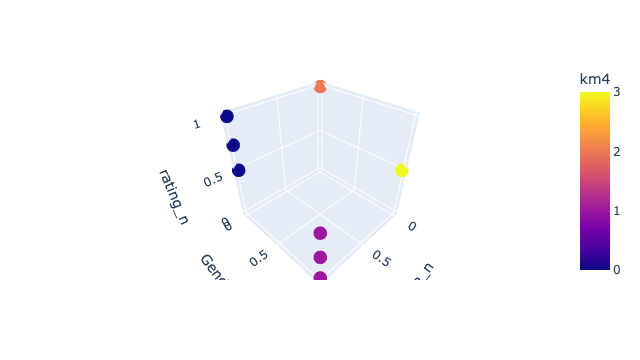

In [63]:
fig = px.scatter_3d(fwp_df, x='Role_n', y='Gender_n', z='rating_n',
              color='km4')
fig.show()

#### Classify unseen data

The model can be used to classify new data that wasn't part of the train/test data.

In [64]:
# Create a dataframe with the new data
new_df = pd.DataFrame([[1,1,5]],columns=['Role_n','Gender_n','rating_n'])

new_df['km4_predict'] = km4.predict(new_df)
new_df

,Role_n,Gender_n,rating_n,km4_predict
0,1,1,5,2


### Supervised ML - Training and Testing

Supervised machine learning algorithms use labeled datasets to predict labels (categorical data) or values (numerical data). As input data is fed into the model, it adjusts its weights until the model has been fitted appropriately. Supervised machine learning algorithms help organizations solve for a variety of real-world problems at scale, such as predicting future income or if a person is going to default a credit.

Supervised machine learning uses a portion of the data (training set) to train a given model to yield the given labels/values. The remainder of the data (test set) can be used to test the effectiveness of the model against the provided labels/values. Once the model is yielding reasonable results, it can be used to predict labels/values for unseen data (data that hasn't been labelled).

- The training dataset includes inputs and correct outputs, which allow the model to learn over time 
- The testing dataset includes inputs and correct outputs but the model is only given the inputs. The model is evaluated by comparing its predicted value (model outputs) to the actual value (correct outputs)


### Linear Regression algorithm

Linear regression is used to identify the relationship between a dependent variable and one or more independent variables and is typically leveraged to make predictions about future outcomes. The results from the linear regression help in predicting an unknown value depending on the relationship with the predicting variables. Linear regression fits a straight line that minimizes the discrepancies between predicted and actual output values. Further information in [Linear regression](https://en.wikipedia.org/wiki/Linear_regression).

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Linear_least_squares_example2.svg/440px-Linear_least_squares_example2.svg.png" style="width:50%">

#### Data

Load and get to know the data.

The included dataset is derived from a [dataset of realestate property prices in Darwin](https://www.kaggle.com/datasets/thedevastator/australian-housing-data-1000-properties-sampled?resource=download) 

In [65]:
file_path = "data/"
file_name = "c2-realestate-nt.csv"
property_df = pd.read_csv(f"{file_path}{file_name}")
property_df

,property,price,bedrooms,bathrooms,parking
0,Apartment,99950,0,1,1
1,Apartment,175000,1,1,1
2,Apartment,180000,1,1,0
3,Apartment,180000,1,1,0
4,Apartment,215000,1,1,1
...,...,...,...,...,...
395,House,899000,5,2,3
396,House,1100000,5,3,6
397,House,650000,6,3,3
398,House,849000,6,4,6


In [66]:
# Get the descriptive statiistics
property_df.describe()

,price,bedrooms,bathrooms,parking
count,4.000000e+02,400.000000,400.000000,400.000000
mean,5.102731e+05,2.655000,1.647500,1.942500
std,2.297508e+05,1.076509,0.590861,1.264195
min,9.995000e+04,0.000000,1.000000,0.000000
25%,3.837500e+05,2.000000,1.000000,1.000000
50%,4.750000e+05,3.000000,2.000000,2.000000
75%,5.900000e+05,3.000000,2.000000,2.000000
max,1.950000e+06,6.000000,5.000000,10.000000


Are their any obvious correlations in the data?

In [67]:

property_corr = property_df[['price','bedrooms','bathrooms','parking']].corr()
property_corr

,price,bedrooms,bathrooms,parking
price,1.000000,0.594463,0.601668,0.455834
bedrooms,0.594463,1.000000,0.584556,0.543392
bathrooms,0.601668,0.584556,1.000000,0.368719
parking,0.455834,0.543392,0.368719,1.000000


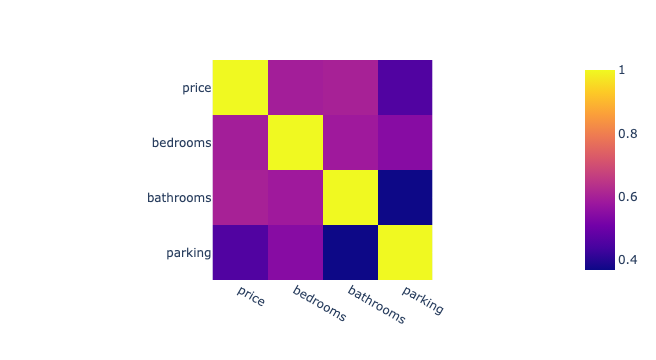

In [68]:
# Create a heatmap to visualise the correlations
pc_fig = px.imshow(property_corr) 
pc_fig.show()

Parking is least correlated with price, so we can leave this out of the model and focus on those variables that correlate most with what we're interested in. Further for this model, we're only interested in numerical data, so we can leave out the property variable also (which is categorical).

In [69]:
price_df = property_df[['price','bedrooms','bathrooms']]
price_df

,price,bedrooms,bathrooms
0,99950,0,1
1,175000,1,1
2,180000,1,1
3,180000,1,1
4,215000,1,1
...,...,...,...
395,899000,5,2
396,1100000,5,3
397,650000,6,3
398,849000,6,4


Different visualisations can sometimes help better understand the relationships in the data. When looking for linear relationships, a pair plot can be helpful...

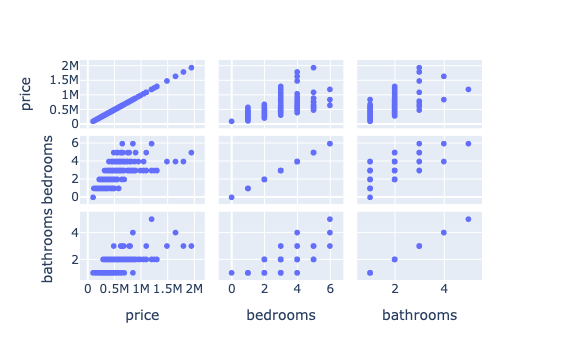

In [70]:
price_fig = px.scatter_matrix(price_df) # Create a pair plot to see the linearity of the variables
price_fig.show()

To fit a linear regression model, we need to assign the dependent variable that we want to predict to the Y-axis, and draw the X-axis data from the independent variables.

In [71]:
# Independent variables

X_data = price_df[['bedrooms','bathrooms']]
X_data

,bedrooms,bathrooms
0,0,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
395,5,2
396,5,3
397,6,3
398,6,4


In [72]:
# Dependent variable

y_data = price_df['price']
y_data

0        99950
1       175000
2       180000
3       180000
4       215000
        ...   
395     899000
396    1100000
397     650000
398     849000
399    1200000
Name: price, Length: 400, dtype: int64

In [73]:
# Break the current dataset into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, shuffle=True, train_size=0.8, random_state=99) # Train size determines the perceptage use for training the model

In [74]:
# Create a new linear regression model
linear_model = LinearRegression() 

# Train the model with the train dataset
linear_model.fit(X_train, y_train) 

# Predict using the testing dataset
linear_predictions = linear_model.predict(X_test) 
linear_predictions

array([369755.96309301, 660068.37470146, 369755.96309301, 288464.32522559,
       578776.73683405, 915526.64644871, 578776.73683405, 288464.32522559,
       578776.73683405, 497485.09896663, 288464.32522559, 497485.09896663,
       497485.09896663, 497485.09896663, 288464.32522559, 497485.09896663,
       578776.73683405, 497485.09896663, 660068.37470146, 451047.60096042,
       660068.37470146, 369755.96309301, 369755.96309301, 288464.32522559,
       660068.37470146, 288464.32522559, 497485.09896663, 451047.60096042,
       451047.60096042, 497485.09896663, 451047.60096042, 451047.60096042,
       578776.73683405, 660068.37470146, 660068.37470146, 660068.37470146,
       451047.60096042, 660068.37470146, 288464.32522559, 660068.37470146,
       706505.87270767, 497485.09896663, 497485.09896663, 288464.32522559,
       741360.01256888, 578776.73683405, 869089.1484425 , 497485.09896663,
       660068.37470146, 578776.73683405, 288464.32522559, 578776.73683405,
       578776.73683405, 2

In [75]:
# Calculate the error between the testing dataset the model's predictions
linear_R2 = r2_score(y_test, linear_predictions) 

print(f'The model R squared score is: {linear_R2}')

The model R squared score is: 0.49796481171499996


The **R-squared** is a coeficient between 0 and 1 that determine the quality of the model prediction. This number indicates the percentage of variance in the dependent variable that the independent variables explain. 0 means that the model's prediction is not explained at all by the independent variables, while 1 means that the model's prediction is 100% explained by the independent variables.

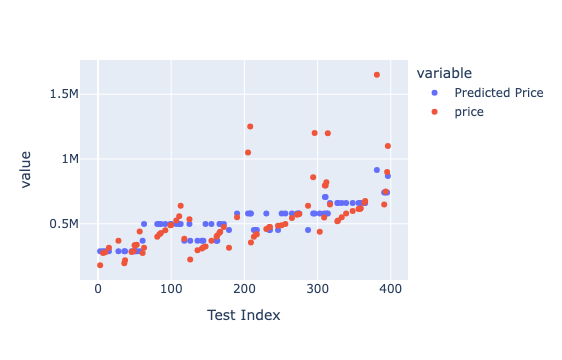

In [76]:
# Create a chart to check the differences between what has been predicted and the real values
y_test_fig_df = pd.DataFrame(y_test)
linear_prediction_fig_df = pd.DataFrame(linear_predictions)
linear_prediction_fig_df.columns = ['Predicted Price']
linear_prediction_fig_df['Test Index'] = y_test_fig_df.index
linear_prediction_fig_df.set_index('Test Index', inplace=True)
linear_fig_df = linear_prediction_fig_df.join(y_test_fig_df)
linear_fig = px.scatter(linear_fig_df)
linear_fig.show()

#### Predict based on new values

In [77]:
# Create a dataframe with the new data
new_df = pd.DataFrame([[4,5],[4,1],[2,3]],columns=['bedrooms','bathrooms'])

new_df['lr_predict'] = linear_model.predict(new_df).astype(int)
new_df.style.format('{:,}')

,bedrooms,bathrooms,lr_predict
0,4,5,"1,043,255"
1,4,1,"532,339"
2,2,3,"625,214"


### Logistic Regression algorithm

While linear regression is leveraged when dependent variables are continuous quantitative data, logistic regression can be used when the dependent variable is categorical. The most common type of logistic regression works with dependent variables with binary values such as "true" and "false" or "yes" and "no." While both regression models seek to understand relationships between data inputs, logistic regression is mainly used to solve binary classification problems. Further information in [Logistic regression](https://en.wikipedia.org/wiki/Logistic_regression).

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cb/Exam_pass_logistic_curve.svg/800px-Exam_pass_logistic_curve.svg.png" style="width: 50%">

#### Data

For this example, we will use the same data as before, except instead of predicting price, we will see if we can predict as 'house' or 'apartment'. While this might not appear to be useful (as we would usually know what a property is), by predicting the relationships, we can identify anomalies. e.g. data that is different than what is expected. This might help with tasks such as setting an appropriate price for sale.

First it is important to understand the balance between values of the dependent variable

In [78]:
property_df.groupby('property').count()

,price,bedrooms,bathrooms,parking
property,,,,
Apartment,216,216,216,216
House,184,184,184,184


These are reasonably balanced so it should not be a problem in the analysis. Skewed data can be problematic as there may not be sufficient data for one dependent value to train an effective model.

As with the linear regression, we need to create separate datasets for dependent, independent, and training and test.

In [79]:
# Independent variables data - start with all options
X_data = property_df[['price','bedrooms','bathrooms','parking']] 

# Dependent variable data
y_data = property_df['property']=='House' # convert to True False 

In [80]:
y_data

0      False
1      False
2      False
3      False
4      False
       ...  
395     True
396     True
397     True
398     True
399     True
Name: property, Length: 400, dtype: bool

In [81]:
# Break the current dataset into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, shuffle=True, train_size=0.8, random_state=99) # Train size determines the perceptage use for training the model

In [82]:
# Check the class balance
y_train.value_counts(normalize=True)

property
False    0.534375
True     0.465625
Name: proportion, dtype: float64

There is a small class inbalance in the variable that we are going to predict. Therefore, the model is likely to predict towards 'No' just because the biased data rather than the independent variables. In any classification model such as logistic regression, decision trees, etc. The class balance need to be considered.

In [83]:
logistic_model = LogisticRegression(class_weight={False: 0.53, True: 0.47})

Additionally, it is a common practice to scale the date to have a better model. To scale the data wwe are going to use standardization that scale the data to have a mean of 0 and a standard deviation of 1.

In [84]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [85]:
# Fit the model to the training dataset
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{False: 0.53, True: 0.47}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of pr

To evaluate the model the most common method is the confusion matrix.

In [86]:
logistic_prediction = logistic_model.predict(X_test) # Use the model to predict based on the testing dataset
cm = confusion_matrix(y_test, logistic_prediction) # Compare the model's prediction against the true value in the testing dataset
cm

array([[42,  3],
       [10, 25]])

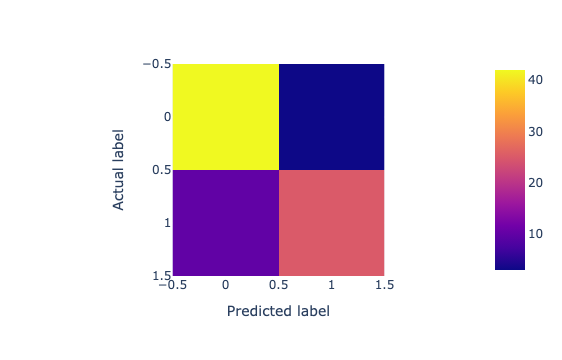

In [87]:
cm_fig = px.imshow(cm, labels={'x': 'Predicted label', 'y': 'Actual label'})
cm_fig.show()

In [88]:
report = classification_report(y_test, logistic_prediction) # Get further evaluation metrics
print(report)

              precision    recall  f1-score   support

       False       0.81      0.93      0.87        45
        True       0.89      0.71      0.79        35

    accuracy                           0.84        80
   macro avg       0.85      0.82      0.83        80
weighted avg       0.84      0.84      0.83        80



#### Precision and Recall

Precision and recall are important factors in understanding the effectiveness of a model.

- Precision: What proportion of positive identifications was actually correct? 
- Recall: What proportion of relevant elements were identified correctly?

See this[Google developers page](https://developers.google.com/machine-learning/crash-course/classification/precision-and-recall) for a helpful explanation.
See this [Wikipedia page](https://en.wikipedia.org/wiki/Precision_and_recall) for more information.


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/700px-Precisionrecall.svg.png" width="30%">

[Image source](https://commons.wikimedia.org/wiki/File:Precisionrecall.svg)

Additional explanations can be found in this [Medium Article](https://medium.com/@nirajan.acharya666/understanding-precision-recall-f1-score-and-support-in-machine-learning-evaluation-7ec935e8512e#:~:text=F1%2Dscore%20is%20useful%20when,of%20instances%20in%20each%20class.)

### Predict a classification on new data

In [89]:
# Create a dataframe with the new data
new_df = pd.DataFrame([[400000,2,1,1],[900000,4,2,2]],columns=['price','bedrooms','bathrooms','parking'])
# Scale the same as the model data
X_new = scale.transform(new_df)
# Predict classification
new_prediction = logistic_model.predict(X_new)
new_df['logist_house_pred'] = new_prediction
new_df

,price,bedrooms,bathrooms,parking,logist_house_pred
0,400000,2,1,1,False
1,900000,4,2,2,True


---

### Further exploration

Take a look at other ML approaches available using the [Scikit-learn library](https://scikit-learn.org/stable/).

Try different approaches with your own data.